# **Data Collection**

## Objectives

* Download data from Kaggle.com and perform an initial EDA.

## Inputs

* unclean_smartwatch_health_data.csv

## Outputs

* ydata-profiling EDA

## Additional Comments

* In case you have any additional comments that don't fit in the previous bullets, please state them here. 

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/Predictive_Analytics_Project'

## Load Data

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv('inputs/smartwatch_health_data_untouched/unclean_smartwatch_health_data.csv').drop("User ID", axis=1)
df.head()

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


Setup custom cleaning transformations

In [5]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Replace 'Very High' with 10 in 'Stress Level' and convert columns to numeric
class DataTypeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Replace 'Very High' with 10 in 'Stress Level'
        X['Stress Level'] = X['Stress Level'].replace('Very High', 10)

        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        X['Stress Level'] = pd.to_numeric(X['Stress Level'], errors='coerce')

        return X


# Reduced for the discretized version of the Stress level variable, as dont need to replace 'Very High' with 10
class DataTypeTransformer2(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert columns to numeric, handling non-numeric values
        X['Sleep Duration (hours)'] = pd.to_numeric(X['Sleep Duration (hours)'], errors='coerce')
        return X

# Impute missing values (not for Activity Level)
from sklearn.impute import KNNImputer

class KNNImputerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=3):
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=self.n_neighbors)

    def fit(self, X, y=None):
        # Identify numerical columns
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.imputer.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        # Impute numerical columns
        X[self.num_cols] = self.imputer.transform(X[self.num_cols])
        return X


# Handle Outliers
from feature_engine.outliers import Winsorizer

class WinsorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.winsorizers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Winsorizers for each variable
        self.winsorizers['Sleep Duration (hours)'] = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.winsorizers['Heart Rate (BPM)'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.winsorizers['Blood Oxygen Level (%)'] = Winsorizer(
            capping_method='iqr', tail='left', fold=1.5, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.winsorizers['Step Count'] = Winsorizer(
            capping_method='iqr', tail='right', fold=1.5, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Winsorizers
        for winsorizer in self.winsorizers.values():
            X = winsorizer.transform(X)
        return X


class FloatToInt(BaseEstimator, TransformerMixin):
    def __init__(self, columns=['Stress Level']):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert specified columns to integer
        for col in self.columns:
            X[col] = X[col].astype(int)
        return X

# Predict missing values in 'Activity Level'
from sklearn.ensemble import RandomForestClassifier

class CategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_column='Activity Level', random_state=42):
        self.target_column = target_column
        self.random_state = random_state
        self.classifier = RandomForestClassifier(random_state=self.random_state)
        self.original_categories = None

    def fit(self, X, y=None):
        X = X.copy()
        # Save original categories
        X[self.target_column] = X[self.target_column].astype('category')
        self.original_categories = X[self.target_column].cat.categories

        # Encode target column
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Split data
        self.train_data = X.dropna(subset=[self.target_column])
        self.test_data = X[X[self.target_column].isna()]

        # Features and target
        self.X_train = self.train_data.drop(columns=[self.target_column])
        self.y_train = self.train_data[self.target_column].astype(int)

        # Fit classifier
        self.classifier.fit(self.X_train, self.y_train)
        return self

    def transform(self, X):
        X = X.copy()
        # Encode target column
        X[self.target_column] = X[self.target_column].astype('category')
        X[self.target_column] = X[self.target_column].cat.codes.replace(-1, np.nan)

        # Identify missing values
        missing_mask = X[self.target_column].isna()
        if missing_mask.any():
            X_missing = X[missing_mask]
            X_missing_features = X_missing.drop(columns=[self.target_column])
            # Predict missing values
            X.loc[missing_mask, self.target_column] = self.classifier.predict(X_missing_features)

        # Convert to int and decode categories
        X[self.target_column] = X[self.target_column].astype(int)
        X[self.target_column] = pd.Categorical.from_codes(
            X[self.target_column], categories=self.original_categories
        )
        return X


# Correct mis-spelled values in Activity Level
class CategoryCorrector(BaseEstimator, TransformerMixin):
    def __init__(self, column='Activity Level'):
        self.column = column
        self.class_mapping = {
            'Seddentary': 'Sedentary',
            'Highly_Active': 'Highly Active',
            'Actve': 'Active'
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = X[self.column].replace(self.class_mapping)
        return X


# Smooth data using K-Nearest Neighbors
from sklearn.neighbors import NearestNeighbors

class DataSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, k=3):
        self.k = k
        self.nn = NearestNeighbors(n_neighbors=self.k)

    def fit(self, X, y=None):
        X = X.copy()
        self.num_cols = X.select_dtypes(include=[np.number]).columns
        self.nn.fit(X[self.num_cols])
        return self

    def transform(self, X):
        X = X.copy()
        distances, indices = self.nn.kneighbors(X[self.num_cols])

        # Smooth numerical columns
        for i, col in enumerate(self.num_cols):
            X[col] = [np.mean(X.iloc[indices[row_idx]][col]) for row_idx in range(len(X))]
        return X


# Trim outliers again after smoothing
from feature_engine.outliers import OutlierTrimmer

class OutlierTrimmerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.trimmers = {}

    def fit(self, X, y=None):
        X = X.copy()
        # Define and fit Outlier Trimmers for each variable
        self.trimmers['Heart Rate (BPM)'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Heart Rate (BPM)']
        ).fit(X)
        self.trimmers['Blood Oxygen Level (%)'] = OutlierTrimmer(
            capping_method='quantiles', tail='left', fold=0.05, variables=['Blood Oxygen Level (%)']
        ).fit(X)
        self.trimmers['Sleep Duration (hours)'] = OutlierTrimmer(
            capping_method='quantiles', tail='both', fold=0.05, variables=['Sleep Duration (hours)']
        ).fit(X)
        self.trimmers['Step Count'] = OutlierTrimmer(
            capping_method='quantiles', tail='right', fold=0.05, variables=['Step Count']
        ).fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        # Apply Outlier Trimmers sequentially
        for trimmer in self.trimmers.values():
            X = trimmer.transform(X)
        return X


from sklearn.preprocessing import MinMaxScaler, StandardScaler
class DataFrameScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_columns=None):
        self.exclude_columns = exclude_columns
        self.scaler = StandardScaler()
    
    def fit(self, X, y=None):
        X_to_scale = X.drop(columns=self.exclude_columns)
        self.scaler.fit(X_to_scale)
        return self
    
    def transform(self, X):
        X_to_scale = X.drop(columns=self.exclude_columns)
        X_excluded = X[self.exclude_columns]
        X_scaled = pd.DataFrame(self.scaler.transform(X_to_scale), columns=X_to_scale.columns)
        X_final = pd.concat([X_scaled, X_excluded.reset_index(drop=True)], axis=1)
        return X_final

## ML pipeline

---

Here we will perform feature selection for the Stress Level variable  to see if there is any suitable or obvious way to predict this variable, or perhaps it is not possible and it better off left as a traditional data analysis problem, which I have already studied. As a foresight from the study, most variables were sligtly correlated, although this could be a large corelation for this dataset as this "acceptance level" with correlation fluctuates per dataset, and correlation of just 0.07 (the highest correlation score between step count and stress level) could be actually quite high.

# Finding the best algorithm for the task

Setup cleaning pipeline

In [6]:
from sklearn.pipeline import Pipeline
# encoding
from feature_engine.encoding import OrdinalEncoder 

def CleanEnginPipeline():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        # I have chosen OrdinalEncoder as our categorical variables have an ordinal relationship
        # ('minmax', DataFrameScaler(exclude_columns=["Activity Level"])),
    ])
    return cleaning_engineering_pipeline

Fit the clean

In [7]:
df_clean = CleanEnginPipeline().fit_transform(df)
df_clean.head()

/tmp/ipykernel_2499/485161542.py:173: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[self.column] = X[self.column].replace(self.class_mapping)


,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,62.184919,97.828229,5451.918817,6.777782,0,3.000000
1,70.066166,98.201064,725.472727,5.762139,0,6.000000
3,44.885946,98.117870,13797.700473,7.177672,1,2.666667
4,57.265092,97.971623,15682.783697,5.786598,0,4.333333
5,83.731238,97.092443,10213.606016,7.742955,0,8.000000


In [8]:
from sklearn.pipeline import Pipeline

### Data Cleaning and Feature Engineering
from feature_engine.imputation import MeanMedianImputer
from feature_engine.imputation import CategoricalImputer
from feature_engine.encoding import OrdinalEncoder
from feature_engine.selection import SmartCorrelatedSelection

### Feat Scaling
from sklearn.preprocessing import StandardScaler

### Feat Selection
from sklearn.feature_selection import SelectFromModel

### ML algorithms 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression



def PipelineOptimization(model):
  pipeline_base = Pipeline([
      ("feat_selection",  SelectFromModel(model) ),

      ("model", model ),
    ])

  return pipeline_base


from sklearn.model_selection import GridSearchCV
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model=  PipelineOptimization(self.models[key])

            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs, verbose=verbose, scoring=scoring)
            gs.fit(X,y)
            self.grid_searches[key] = gs    

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                 'estimator': key,
                 'min_score': min(scores),
                 'max_score': max(scores),
                 'mean_score': np.mean(scores),
                 'std_score': np.std(scores),
            }
            return pd.Series({**params,**d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]        
                scores.append(r.reshape(len(params),1))

            all_scores = np.hstack(scores)
            for p, s in zip(params,all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score', 'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches


models_search = {
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "LinearRegression": LinearRegression(),
    "xgb": XGBRegressor(random_state=42),
}

params_search = {
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "GradientBoostingRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "LinearRegression": {},
    "xgb": {},
}

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_clean.drop(['Stress Level'],axis=1),
                                                    df_clean['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

* Train set: (6237, 5) (6237,) 
* Test set: (1560, 5) (1560,)


In [10]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring='neg_root_mean_squared_error',
           n_jobs=-1,
           cv=2)  

print("Best algorithms for predicting Stress Level")
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary


Running GridSearchCV for DecisionTreeRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for LinearRegression 

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for xgb 

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best algorithms for predicting Stress Level


,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,-1.772031,-1.747183,-1.722336,0.024847
1,RandomForestRegressor,-1.785108,-1.763191,-1.741274,0.021917
2,GradientBoostingRegressor,-1.919715,-1.902376,-1.885037,0.017339
6,xgb,-1.96661,-1.918706,-1.870802,0.047904
4,AdaBoostRegressor,-1.953068,-1.934534,-1.915999,0.018534
5,LinearRegression,-1.957883,-1.937763,-1.917643,0.02012
0,DecisionTreeRegressor,-2.420211,-2.418677,-2.417142,0.001534


Extra Trees Regressor performes the best when the target is Stress Levels, it deviates by approximatley -0.165815 from the actual awnser

In [11]:
models_search = {
    'ExtraTreesRegressor': ExtraTreesRegressor(random_state=42)
}

params_search = {
    'ExtraTreesRegressor': {
        'model__n_estimators': [50, 150, 200],
        'model__criterion': ['absolute_error']
    }
}

In [12]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train,
           scoring='r2',
           n_jobs=-1,
           cv=2)  


# method .score_summary returns a DataFrame with all the training results summary and a dictionary containing all pipelines.
print("Best algorithms for predicting Stress Level")
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary


Running GridSearchCV for ExtraTreesRegressor 

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best algorithms for predicting Stress Level


,estimator,min_score,mean_score,max_score,std_score,model__criterion,model__n_estimators
2,ExtraTreesRegressor,0.189136,0.201488,0.21384,0.012352,absolute_error,200
1,ExtraTreesRegressor,0.188318,0.200491,0.212664,0.012173,absolute_error,150
0,ExtraTreesRegressor,0.188992,0.196017,0.203042,0.007025,absolute_error,50


In [13]:
best_model = grid_search_summary.iloc[0, 0]
grid_search_pipelines[best_model].best_params_

{'model__criterion': 'absolute_error', 'model__n_estimators': 200}

In [14]:

best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline

Pipeline(steps=[('feat_selection',
                 SelectFromModel(estimator=ExtraTreesRegressor(random_state=42))),
                ('model',
                 ExtraTreesRegressor(criterion='absolute_error',
                                     n_estimators=200, random_state=42))])

* The pipeline has 6 features after data cleaning and feature engineering.
* These are the 4 most important features in descending order. The model was trained on them: 
['Step Count', 'Heart Rate (BPM)', 'Sleep Duration (hours)', 'Blood Oxygen Level (%)']


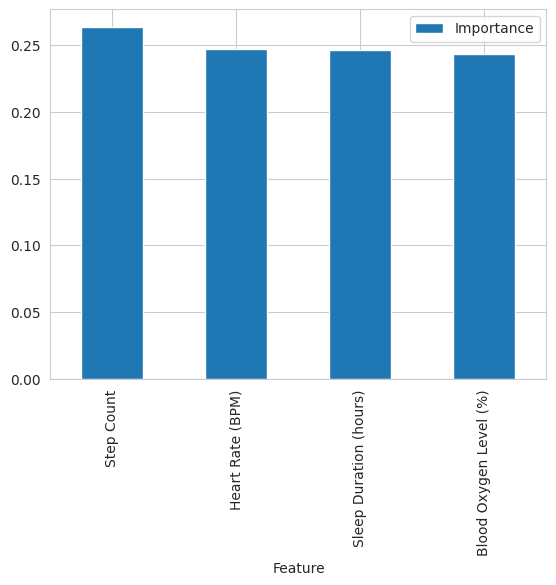

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# after data cleaning and feature engineering, the features may have changes
# how many data cleaning and feature engineering steps does your pipeline have?
columns_after_data_cleaning_feat_eng = df_clean.columns.to_list()
print(f"* The pipeline has {len(columns_after_data_cleaning_feat_eng)} features after data cleaning and feature engineering.")

# Ensure the indices are within bounds
support = best_regressor_pipeline['feat_selection'].get_support()
best_features = [columns_after_data_cleaning_feat_eng[i] for i in range(len(support)) if support[i]]

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': best_features,
    'Importance': best_regressor_pipeline['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    prediction = pipeline.predict(X)
    print('R2 Score:', r2_score(y, prediction).round(3))
    print('Mean Absolute Error:', mean_absolute_error(y, prediction).round(3))
    print('Mean Squared Error:', mean_squared_error(y, prediction).round(3))
    print('Root Mean Squared Error:', np.sqrt(
        mean_squared_error(y, prediction)).round(3))
    print("\n")


def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    plt.show()

Model Evaluation 

* Train Set
R2 Score: 0.806
Mean Absolute Error: 0.675
Mean Squared Error: 0.725
Root Mean Squared Error: 0.852


* Test Set
R2 Score: 0.36
Mean Absolute Error: 1.22
Mean Squared Error: 2.437
Root Mean Squared Error: 1.561




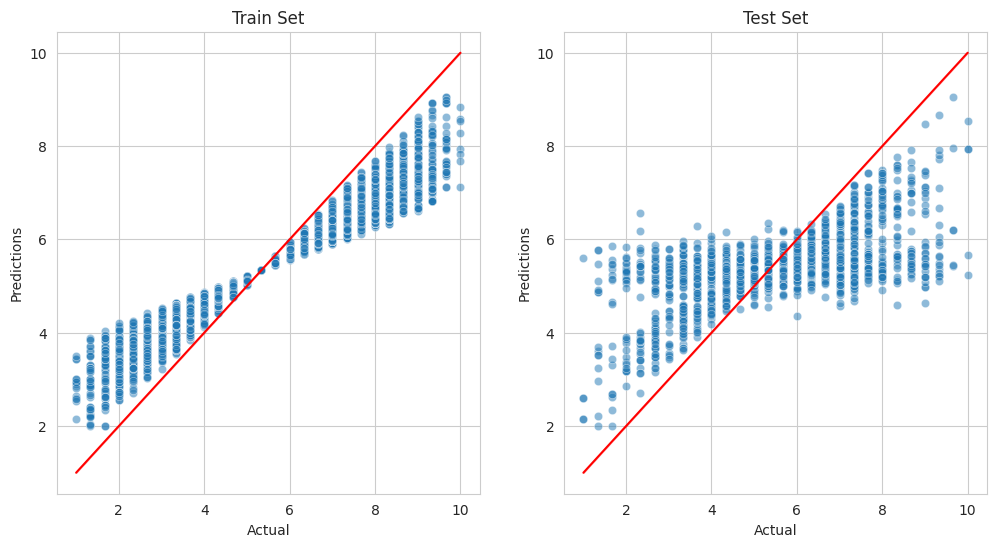

In [17]:
regression_performance(X_train, y_train, X_test, y_test, best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test, best_regressor_pipeline)

---

## Regression with PCA

In [18]:
from sklearn.decomposition import PCA

def PCAPipeline():
    pca_pipeline = Pipeline([
        ('cleaning_engineering', CleanEnginPipeline()),
        ('pca', PCA(n_components=4)),
        ('model', best_regressor_pipeline)
    ])
    return pca_pipeline

In [19]:
pipeline = PCAPipeline()
pipeline_pca = Pipeline(pipeline.steps[:2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:97: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return is_numeric(pd.to_numeric(column, errors="ignore"))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))

(7797, 4) 
 <class 'numpy.ndarray'>


* The 3 components explain 100.0% of the data 



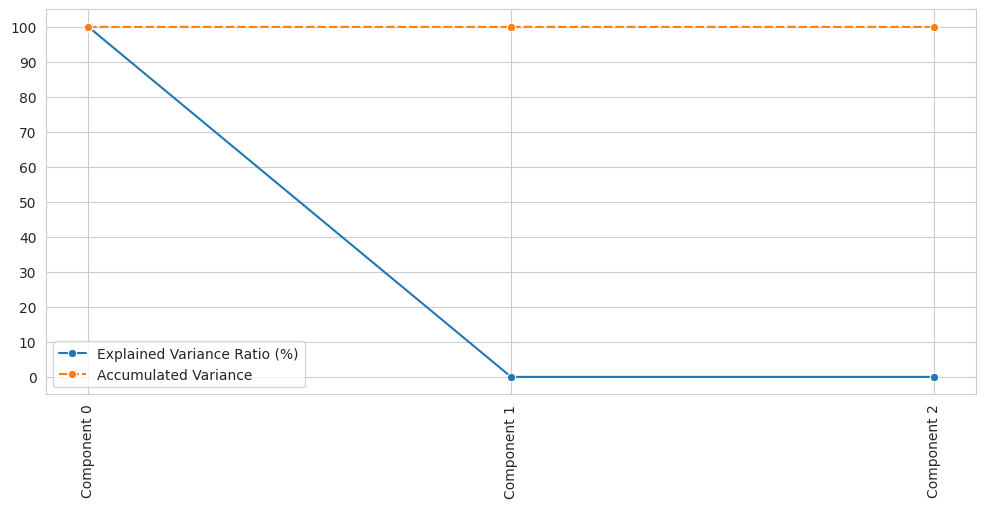

In [20]:
import numpy as np
from sklearn.decomposition import PCA

n_components = 3


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)
    x_PCA = pca.transform(df_pca)

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = dfExplVarRatio['Explained Variance Ratio (%)'].cumsum(
    )

    PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum(
    )

    print(
        f"* The {n_components} components explain {round(PercentageOfDataExplained,2)}% of the data \n")
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=dfExplVarRatio,  marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)

In [21]:
models_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    "XGBRegressor": XGBRegressor(random_state=0),
}

params_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    "XGBRegressor": {},
}

In [22]:
pipeline = PCAPipeline()
pipeline_pca = Pipeline(pipeline.steps[:2])
df_pca = pipeline_pca.fit_transform(df)
df_pca = pd.DataFrame(df_pca, columns=[f"Component {i}" for i in range(pipeline_pca.named_steps['pca'].n_components_)])

print(df_pca.shape, '\n', type(df_pca))

/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:97: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return is_numeric(pd.to_numeric(column, errors="ignore"))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))

(7797, 4) 
 <class 'pandas.core.frame.DataFrame'>


In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_pca,
                                                    df_clean['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

* Train set: (6237, 4) (6237,) 
* Test set: (1560, 4) (1560,)


In [24]:
quick_search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
quick_search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)
grid_search_summary, grid_search_pipelines = quick_search.score_summary(sort_by='mean_score')
grid_search_summary


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,min_score,mean_score,max_score,std_score
1,DecisionTreeRegressor,1.0,1.0,1.0,0.0
2,RandomForestRegressor,1.0,1.0,1.0,0.0
5,GradientBoostingRegressor,1.0,1.0,1.0,0.0
3,ExtraTreesRegressor,0.999994,0.999997,0.999999,0.000002
6,XGBRegressor,0.999311,0.999367,0.999475,0.000057
0,LinearRegression,0.999322,0.999355,0.999384,0.000022
4,AdaBoostRegressor,0.979522,0.983155,0.98885,0.003115


In [25]:
best_model = grid_search_summary.iloc[0,0]
grid_search_pipelines[best_model].best_params_

best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline


Pipeline(steps=[('feat_selection',
                 SelectFromModel(estimator=DecisionTreeRegressor(random_state=0))),
                ('model', DecisionTreeRegressor(random_state=0))])

Model Evaluation 

* Train Set
R2 Score: 1.0
Mean Absolute Error: 0.0
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0


* Test Set
R2 Score: 1.0
Mean Absolute Error: 0.0
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0




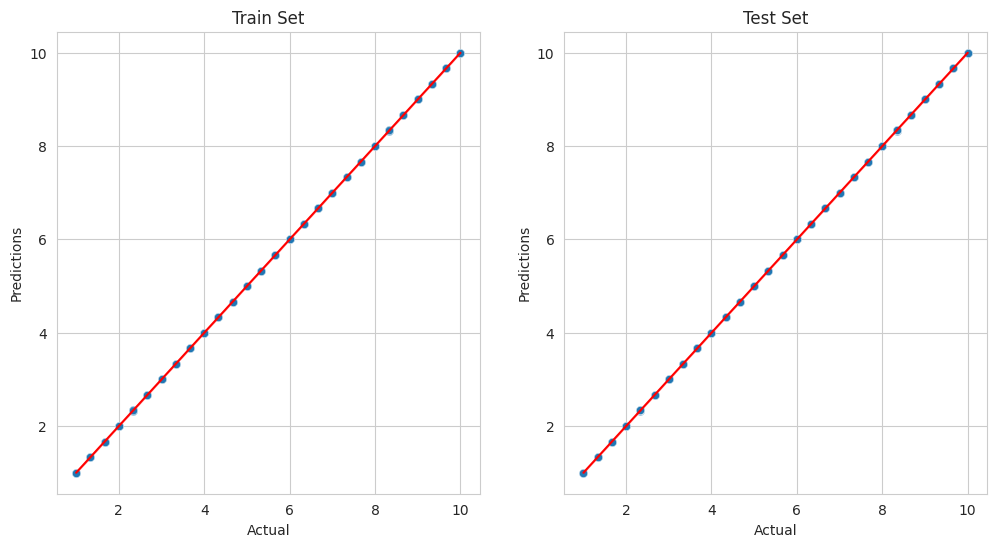

In [26]:
regression_performance(X_train, y_train, X_test, y_test,best_regressor_pipeline)
regression_evaluation_plots(X_train, y_train, X_test, y_test,
                            best_regressor_pipeline)

This seems to have done very well

## Convert to a classification task

In [27]:

def CleanEnginPipelineDisc():
    cleaning_engineering_pipeline = Pipeline([
        ('data_type_transformer', DataTypeTransformer()),
        ('knn_imputer', KNNImputerTransformer(n_neighbors=3)),
        ('winsorizer_transformer', WinsorizerTransformer()),
        ('categorical_imputer', CategoricalImputer()),
        ('category_corrector', CategoryCorrector()),
        ('float_to_int', FloatToInt()),
        ('data_smoother', DataSmoother(k=3)),
        ('outlier_trimmer_transformer', OutlierTrimmerTransformer()),
        ('encoder', OrdinalEncoder(encoding_method='arbitrary', variables=["Activity Level"])),
        ('minmax', DataFrameScaler(exclude_columns=["Activity Level", "Stress Level"])),
    ])
    return cleaning_engineering_pipeline

In [28]:
pipeline = CleanEnginPipelineDisc()
df_discret = pipeline.fit_transform(df)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_discret.drop(columns=['Stress Level']),
                                                    df_discret['Stress Level'],
                                                    test_size=0.2,
                                                    random_state=42)

print("* Train set:", X_train.shape, y_train.shape, "\n* Test set:",  X_test.shape, y_test.shape)

/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:97: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  return is_numeric(pd.to_numeric(column, errors="ignore"))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/variable_manipulation.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return is_datetime(pd.to_datetime(column, errors="ignore", utc=True))

* Train set: (6237, 5) (6237,) 
* Test set: (1560, 5) (1560,)


In [29]:
from feature_engine.discretisation import ArbitraryDiscretiser

stress_map = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
disc = ArbitraryDiscretiser(binning_dict={'Stress Level': stress_map}, return_object=True)
y_train = disc.fit_transform(y_train.to_frame())
y_test = disc.transform(y_test.to_frame())

disc.binner_dict_['Stress Level']

n_classes = len(stress_map) - 1
classes_ranges = disc.binner_dict_['Stress Level'][1:-1]

labels_map = {}
for n in range(0, n_classes):
    if n == 0:
        labels_map[n] = f"<{classes_ranges[0]}"
    elif n == n_classes-1:
        labels_map[n] = f"+{classes_ranges[-1]}"
    else:
        labels_map[n] = f"{classes_ranges[n-1]} to {classes_ranges[n]}"

labels_map

y_train = y_train.replace(labels_map)
y_test = y_test.replace(labels_map)
y_train.head(20)


,Stress Level
5566,2 to 3
5875,4 to 5
5943,7 to 8
904,5 to 6
1446,2 to 3
7310,5 to 6
3745,3 to 4
7345,5 to 6
3139,4 to 5
3973,4 to 5


In [30]:
models_search = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(),
}

params_search = {
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
    "LogisticRegression": {},
}

In [31]:
# Convert numeric bins to string labels
y_train = y_train.astype(str)
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train.values.ravel(),
                 cv=5,
                 n_jobs=-1,
                 verbose=1,
                 scoring='accuracy')


Running GridSearchCV for DecisionTreeClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [32]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
best_model = grid_search_summary.iloc[0,0]
pipeline_clf = grid_search_pipelines[best_model].best_estimator_
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
1,RandomForestClassifier,0.421812,0.430497,0.455493,0.01266
3,ExtraTreesClassifier,0.423878,0.428091,0.435445,0.004028
0,DecisionTreeClassifier,0.414595,0.423119,0.427885,0.004626
2,GradientBoostingClassifier,0.275862,0.279943,0.288693,0.004498
5,LogisticRegression,0.181235,0.183261,0.184295,0.00105
4,AdaBoostClassifier,0.101844,0.137565,0.169872,0.026291


* The pipeline has 6 features after data cleaning and feature engineering.
* These are the 4 most important features in descending order. The model was trained on them: 
['Step Count', 'Heart Rate (BPM)', 'Sleep Duration (hours)', 'Blood Oxygen Level (%)']


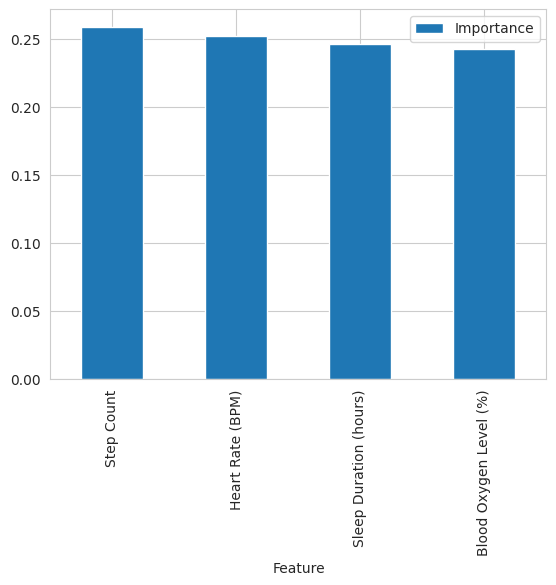

In [33]:
# after data cleaning and feature engineering, the features may have changes
# how many data cleaning and feature engineering steps does your pipeline have?
columns_after_data_cleaning_feat_eng = df_clean.columns.to_list()
print(f"* The pipeline has {len(columns_after_data_cleaning_feat_eng)} features after data cleaning and feature engineering.")

# Ensure the indices are within bounds
support = pipeline_clf['feat_selection'].get_support()
best_features = [columns_after_data_cleaning_feat_eng[i] for i in range(len(support)) if support[i]]

# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
    'Feature': best_features,
    'Importance': pipeline_clf['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()

It seems step count is the best predictor for Stress Level as a categoric datatype

In [34]:
from sklearn.metrics import classification_report, confusion_matrix


def confusion_matrix_and_report(X, y, pipeline, label_map):

    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(confusion_matrix(y_true=prediction, y_pred=y),
          columns=[["Actual " + sub for sub in label_map]],
          index=[["Prediction " + sub for sub in label_map]]
          ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")


def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

In [35]:
y_train.value_counts()

Stress Level
5 to 6          1144
4 to 5          1009
6 to 7          1006
3 to 4           916
7 to 8           758
2 to 3           592
8 to 9           438
1 to 2           247
+9               111
<1                16
Name: count, dtype: int64

In [36]:
def DiscretPipeline():
    pipeline = Pipeline([
        ('feature_selection', SelectFromModel(estimator=ExtraTreesClassifier())),
        ('model',  ExtraTreesClassifier())
    ])
    return pipeline

In [37]:
pipeline = DiscretPipeline()

# Convert continuous Stress Level to discrete class labels
y_train = y_train.astype(str)
y_test = y_test.astype(str)

# Fit the pipeline before using it for predictions
pipeline.fit(X_train, y_train.values.ravel())

# Ensure label_map is a list of strings
label_map = [str(label) for label in y_train.value_counts().index.to_list()]

clf_performance(X_train=X_train, y_train=y_train.values.ravel(),
                X_test=X_test, y_test=y_test.values.ravel(),
                pipeline=pipeline,
                label_map=label_map)

#### Train Set #### 

---  Confusion Matrix  ---
                       Actual ('5 to 6',) Actual ('4 to 5',)  \
Prediction ('5 to 6',)                111                  0   
Prediction ('4 to 5',)                  0                247   
Prediction ('6 to 7',)                  0                  0   
Prediction ('3 to 4',)                  0                  0   
Prediction ('7 to 8',)                  0                  0   
Prediction ('2 to 3',)                  0                  0   
Prediction ('8 to 9',)                  0                  0   
Prediction ('1 to 2',)                  0                  0   
Prediction ('+9',)                      0                  0   
Prediction ('<1',)                      0                  0   

                       Actual ('6 to 7',) Actual ('3 to 4',)  \
Prediction ('5 to 6',)                  0                  0   
Prediction ('4 to 5',)                  0                  0   
Prediction ('6 to 7',)                592             

Not bad, quickly moving on to the next modelling task, will return to polish. Limited time

# Section 2 EDA

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)
